# SilkRoute Benchmark — 03: Returns, Inventory & Stockouts
Operational narratives and stress signals.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = "../silkroute_benchmark_out"  # adjust if needed

with open(f"{OUT}/seed_manifest.json","r", encoding="utf-8") as f:
    manifest = json.load(f)

def load_table(name):
    return pd.read_parquet(f"{OUT}/{name}.parquet")

channels = load_table("channels")
stores = load_table("stores")
salespeople = load_table("salespeople")
customers = load_table("customers")
products = load_table("products")
skus = load_table("product_variants_skus")
variant_attributes = load_table("variant_attributes")
cat_attr_defs = load_table("category_attribute_definitions")
promotions = load_table("promotions")
transactions = load_table("transactions")
lines = load_table("transaction_lines")
inventory = load_table("inventory_snapshots")
returns = load_table("returns")

transactions["transaction_ts"] = pd.to_datetime(transactions["transaction_ts"])
transactions["month"] = transactions["transaction_ts"].dt.to_period("M").astype(str)

lines = lines.merge(
    transactions[["transaction_id","transaction_ts","month","channel_type","store_id","customer_id","salesperson_id"]],
    on="transaction_id", how="left"
)
lines = lines.merge(skus[["sku_id","product_id","base_price"]], on="sku_id", how="left")
lines = lines.merge(products[["product_id","category","subcategory","brand"]], on="product_id", how="left")

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
promotions["start_date"] = pd.to_datetime(promotions["start_date"])
promotions["end_date"] = pd.to_datetime(promotions["end_date"])

hero_skus = set(manifest["pattern_sets"].get("hero_skus", []))
high_return_skus = set(manifest["pattern_sets"].get("high_return_skus", []))
top_salespeople = set(manifest["people_sets"].get("top_salespeople", []))
discount_heavy_salespeople = set(manifest["people_sets"].get("discount_heavy_salespeople", []))
underperforming_stores = set(manifest["meta"].get("underperforming_stores", []))
discount_heavy_stores = set(manifest["meta"].get("discount_heavy_stores", []))

def pct(x):
    return 100.0 * x


## A. Returns: tx-level rate by segment

In [3]:
if len(returns)==0:
    print("No returns table found.")
else:
    tx_seg = transactions.merge(customers[["customer_id","segment"]], on="customer_id", how="left")
    ret_tx = returns[["transaction_id"]].drop_duplicates()
    tx_seg["has_return"] = tx_seg["transaction_id"].isin(ret_tx["transaction_id"])
    seg_rate = tx_seg.groupby("segment")["has_return"].mean().sort_values(ascending=False)
    seg_rate


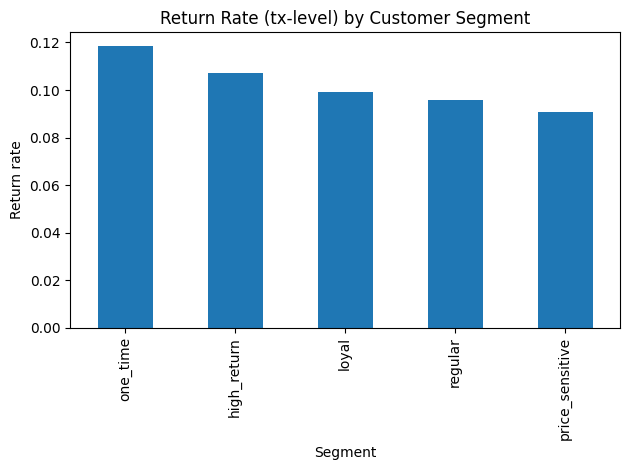

In [4]:
if len(returns):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    seg_rate.plot(kind="bar", ax=ax)
    ax.set_title("Return Rate (tx-level) by Customer Segment")
    ax.set_xlabel("Segment"); ax.set_ylabel("Return rate")
    plt.tight_layout()
    plt.show()


## B. Return outliers with seeded ground truth

In [5]:
if len(returns):
    ret_counts = returns.groupby("sku_id").size().rename("returns")
    sold_counts = lines.groupby("sku_id").size().rename("sold_lines")
    rr = pd.concat([ret_counts, sold_counts], axis=1).fillna(0)
    rr["return_rate_proxy"] = np.where(rr["sold_lines"]>0, rr["returns"]/rr["sold_lines"], 0.0)
    rr = rr.sort_values("return_rate_proxy", ascending=False).reset_index()
    rr["is_high_return_seeded"] = rr["sku_id"].isin(high_return_skus)
    rr.head(30)


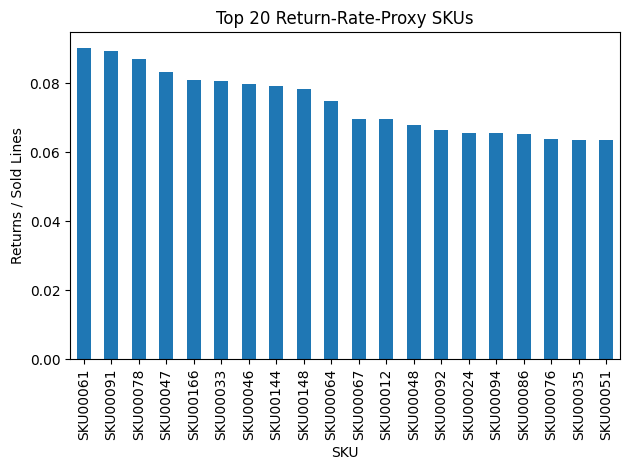

In [6]:
if len(returns):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    rr.head(20).set_index("sku_id")["return_rate_proxy"].plot(kind="bar", ax=ax)
    ax.set_title("Top 20 Return-Rate-Proxy SKUs")
    ax.set_xlabel("SKU"); ax.set_ylabel("Returns / Sold Lines")
    plt.tight_layout()
    plt.show()


## C. Return reasons by category

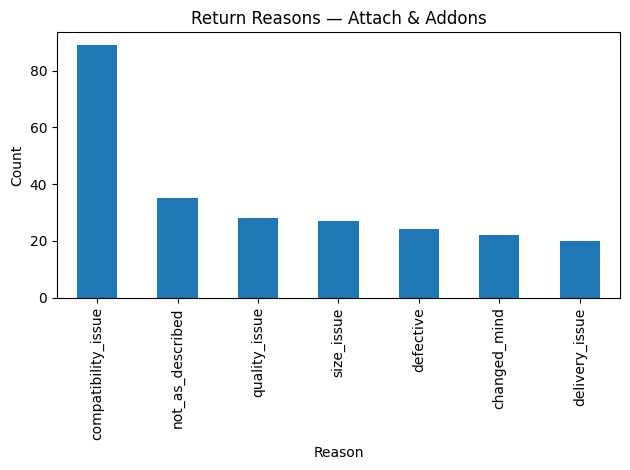

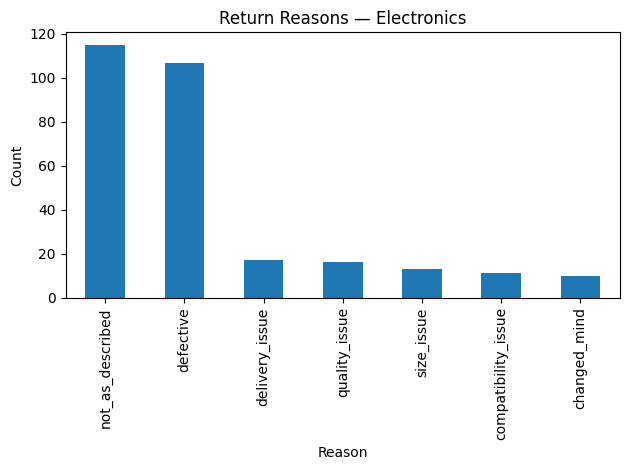

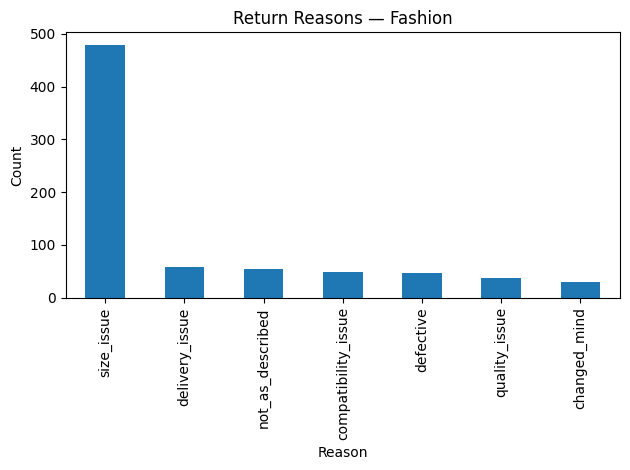

In [7]:
if len(returns):
    ret2 = returns.merge(skus[["sku_id","product_id"]], on="sku_id", how="left").merge(products[["product_id","category"]], on="product_id", how="left")
    reason_cat = ret2.groupby(["category","return_reason"]).size().rename("n").reset_index()

    for cat in reason_cat["category"].unique():
        tmp = reason_cat[reason_cat["category"]==cat].set_index("return_reason")["n"].sort_values(ascending=False)
        fig = plt.figure()
        ax = fig.add_subplot(111)
        tmp.plot(kind="bar", ax=ax)
        ax.set_title(f"Return Reasons — {cat}")
        ax.set_xlabel("Reason"); ax.set_ylabel("Count")
        plt.tight_layout()
        plt.show()


## D. Inventory stockouts — hero vs non-hero

In [8]:
inv = inventory.copy()
inv["is_stockout"] = (inv["stock_on_hand"] <= 0).astype(int)
inv["is_hero"] = inv["sku_id"].isin(hero_skus).astype(int)

stockout_rate = inv.groupby("is_hero")["is_stockout"].mean()
stockout_rate


is_hero
0    0.000732
1    0.078706
Name: is_stockout, dtype: float64

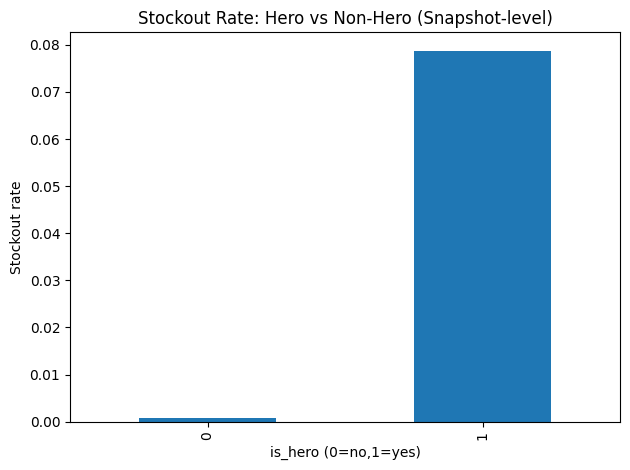

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)
stockout_rate.plot(kind="bar", ax=ax)
ax.set_title("Stockout Rate: Hero vs Non-Hero (Snapshot-level)")
ax.set_xlabel("is_hero (0=no,1=yes)"); ax.set_ylabel("Stockout rate")
plt.tight_layout()
plt.show()


## E. Monthly stockout trend (hero vs non-hero)

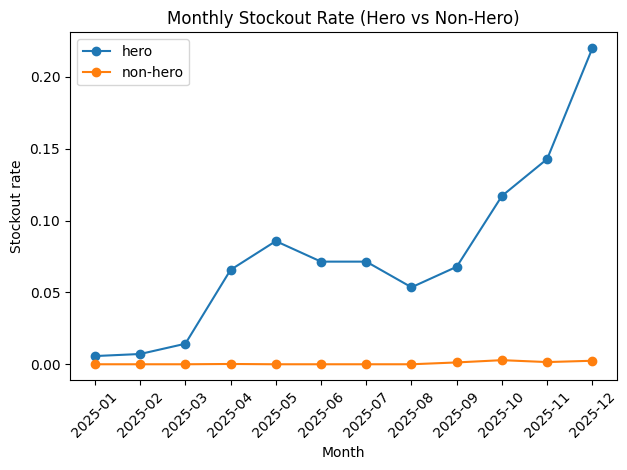

In [10]:
inv["month"] = inv["snapshot_date"].dt.to_period("M").astype(str)
hero_month = inv[inv["sku_id"].isin(hero_skus)].groupby("month")["is_stockout"].mean()
nonhero_month = inv[~inv["sku_id"].isin(hero_skus)].groupby("month")["is_stockout"].mean()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(hero_month.index, hero_month.values, marker="o")
ax.plot(nonhero_month.index, nonhero_month.values, marker="o")
ax.set_title("Monthly Stockout Rate (Hero vs Non-Hero)")
ax.set_xlabel("Month"); ax.set_ylabel("Stockout rate")
ax.legend(["hero","non-hero"], loc="best")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## F. Location stockouts (including S000/DC)

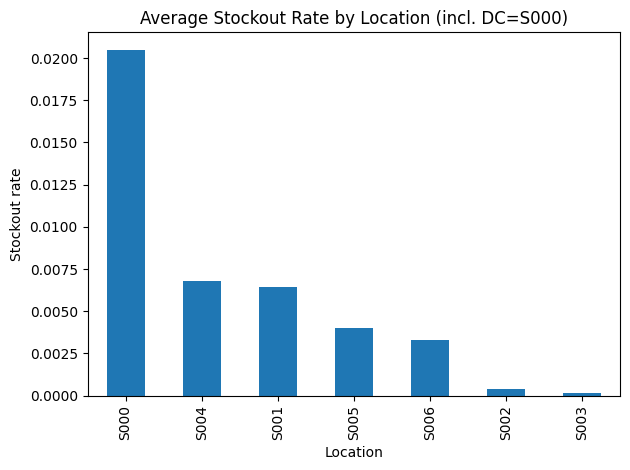

store_id
S000    0.020503
S004    0.006792
S001    0.006415
S005    0.004025
S006    0.003270
S002    0.000377
S003    0.000126
Name: is_stockout, dtype: float64

In [11]:
loc_stockout = inv.groupby("store_id")["is_stockout"].mean().sort_values(ascending=False)
fig = plt.figure()
ax = fig.add_subplot(111)
loc_stockout.plot(kind="bar", ax=ax)
ax.set_title("Average Stockout Rate by Location (incl. DC=S000)")
ax.set_xlabel("Location"); ax.set_ylabel("Stockout rate")
plt.tight_layout()
plt.show()

loc_stockout


## G. Lost-sales proxy (optional)

In [12]:
tx_loc = transactions.copy()
tx_loc["inv_loc"] = np.where(tx_loc["channel_type"]=="online", "S000", tx_loc["store_id"])

line_loc = lines.merge(tx_loc[["transaction_id","inv_loc"]], on="transaction_id", how="left")
line_loc["month"] = line_loc["transaction_ts"].dt.to_period("M").astype(str)

demand = line_loc.groupby(["inv_loc","month","sku_id"])["quantity"].sum().rename("demand_qty").reset_index()
stockout = inv[inv["stock_on_hand"]<=0].groupby(["store_id","month","sku_id"]).size().rename("stockout_snaps").reset_index()

lost = stockout.merge(demand, left_on=["store_id","month","sku_id"], right_on=["inv_loc","month","sku_id"], how="left")
lost["demand_qty"] = lost["demand_qty"].fillna(0)
lost = lost[lost["demand_qty"]>0]

lost_sku = lost.groupby("sku_id").agg(
    months_affected=("month","nunique"),
    total_demand=("demand_qty","sum"),
    stockout_snaps=("stockout_snaps","sum"),
).sort_values(["months_affected","total_demand"], ascending=False)

lost_sku.head(25)


,months_affected,total_demand,stockout_snaps
sku_id,,,
SKU00085,11,161,36
SKU00022,10,193,64
SKU00162,9,200,43
SKU00087,8,139,38
SKU00077,7,123,25
SKU00082,7,118,21
SKU00035,7,89,17
SKU00071,6,75,21
SKU00137,5,62,10
